# 2. Applying ML Algorithms to IoT-23 Data

## 1. Load the data

In [1]:
import pandas as pd

mirai = pd.read_csv('Mirai-34-1.csv')
print('Mirai:', mirai.shape)

Mirai: (23145, 21)


## 2. Extract the labels

The last CSV column contains three space-separated fields. Split them and encode Benign = 0, Malicious = 1.

In [2]:
last_column = mirai.pop('tunnel_parents   label   detailed-label')
mirai[['tunnel_parents', 'label', 'detailed_label']] = last_column.str.split(expand=True)
assert mirai['label'].isin(['Benign', 'Malicious']).all()
mirai['label'] = mirai['label'].map({'Benign': 0, 'Malicious': 1})

mirai.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,local_resp,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,label,detailed_label
0,1.545404e+09,CrDn63WjJEmrWGjqf,192.168.1.195,41040,185.244.25.235,80,tcp,-,3.139211,0,...,-,0,S,3,180,0,0,-,0,-
1,1.545404e+09,CY9lJW3gh1Eje4usP6,192.168.1.195,41040,185.244.25.235,80,tcp,-,-,-,...,-,0,S,1,60,0,0,-,0,-
2,1.545404e+09,CcFXLynukEDnUlvgl,192.168.1.195,41040,185.244.25.235,80,tcp,-,-,-,...,-,0,S,1,60,0,0,-,0,-
3,1.545404e+09,CDrkrSobGYxHhYfth,192.168.1.195,41040,185.244.25.235,80,tcp,http,1.477656,149,...,-,2896,ShADadttcfF,94,5525,96,139044,-,0,-
4,1.545404e+09,CTWZQf2oJSvq6zmPAc,192.168.1.195,41042,185.244.25.235,80,tcp,-,3.147116,0,...,-,0,S,3,180,0,0,-,0,-


## 3. Class distribution

Count both classes before preprocessing.

In [3]:
class_counts = mirai['label'].value_counts().sort_index().to_frame('Count')
class_counts.index = ['Benign (0)', 'Attack (1)']

print('Class counts:')
print(class_counts)
print('\nClass percentages:')
print((class_counts / len(mirai) * 100).round(2))

Class counts:
            Count
Benign (0)   1923
Attack (1)  21222

Class percentages:
            Count
Benign (0)   8.31
Attack (1)  91.69


## 4. Check data quality

Count missing or unspecified feature values (`-` and `(empty)`) and duplicate records. No rows are removed.

In [4]:
missing_counts = (mirai.isna() | mirai.isin(['-', '(empty)'])).sum()
missing_counts = missing_counts.drop(index=['label', 'detailed_label', 'tunnel_parents'])

print(missing_counts[missing_counts > 0])
print('\nDuplicate rows:', mirai.duplicated().sum())
print('Duplicate UIDs:', mirai['uid'].duplicated().sum())

service       21298
duration      17824
orig_bytes    17824
resp_bytes    17824
local_orig    23145
local_resp    23145
dtype: int64

Duplicate rows: 0
Duplicate UIDs: 0


## 5. Clean and select features

Keep traffic statistics and three categorical features. Convert missing numeric values to `NaN`.

In [5]:
import numpy as np

numeric_features = [
    'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes',
    'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes'
]
categorical_features = ['proto', 'service', 'conn_state']

def prepare_features(df):
    X = df[numeric_features + categorical_features].copy()
    X[numeric_features] = X[numeric_features].replace('-', np.nan).astype(float)
    X[categorical_features] = X[categorical_features].replace('-', 'Unknown')
    return X, df['label'].copy()

X, y = prepare_features(mirai)
print('Features:', X.shape[1])
print('Missing numeric values:', int(X[numeric_features].isna().sum().sum()))

Features: 11
Missing numeric values: 53472


## 6. Split the Mirai data

Create stratified training, validation and test sets (70/15/15).

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

for name, target in [('Train', y_train), ('Validation', y_validation), ('Test', y_test)]:
    print(name, len(target), target.value_counts(normalize=True).round(3).to_dict())

Train 16201 {1: 0.917, 0: 0.083}
Validation 3472 {1: 0.917, 0: 0.083}
Test 3472 {1: 0.917, 0: 0.083}


## 7. Preprocessing

Impute and scale numeric features. Encode categorical features. The transformer will be fitted inside each model pipeline.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])

## 8. Model tuning

Tune the four required models on the validation set using macro F1.

In [8]:
from sklearn.base import clone
from sklearn.metrics import f1_score
from sklearn.model_selection import ParameterGrid
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

model_settings = {
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, None],
         'min_samples_leaf': [1, 5], 'class_weight': [None, 'balanced']}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 11], 'weights': ['uniform', 'distance'], 'p': [1, 2]}
    ),
    'Logistic Regression': (
        LogisticRegression(max_iter=2000, solver='liblinear', random_state=42),
        {'C': [0.1, 1, 10], 'class_weight': [None, 'balanced']}
    ),
    'Linear SVM': (
        LinearSVC(max_iter=10000, random_state=42),
        {'C': [0.1, 1, 10], 'class_weight': [None, 'balanced']}
    )
}

def tune_model(estimator, parameter_grid):
    best_score, best_params = -1, None
    best_train_score = None
    for params in ParameterGrid(parameter_grid):
        model = Pipeline([
            ('preprocessor', clone(preprocessor)),
            ('model', clone(estimator).set_params(**params))
        ])
        model.fit(X_train, y_train)
        validation_score = f1_score(
            y_validation, model.predict(X_validation), average='macro'
        )
        if validation_score > best_score:
            best_score = validation_score
            best_params = params
            best_train_score = f1_score(
                y_train, model.predict(X_train), average='macro'
            )
    return best_params, best_train_score, best_score

selected_parameters = {}
validation_rows = []
for name, (estimator, parameter_grid) in model_settings.items():
    params, train_score, validation_score = tune_model(estimator, parameter_grid)
    selected_parameters[name] = params
    validation_rows.append({
        'Model': name, 'Train macro F1': train_score,
        'Validation macro F1': validation_score, 'Parameters': params
    })

validation_results = pd.DataFrame(validation_rows).set_index('Model')
pd.set_option('display.max_colwidth', None)
validation_results

,Train macro F1,Validation macro F1,Parameters
Model,,,
Decision Tree,0.985689,0.990382,"{'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1}"
KNN,0.985284,0.990382,"{'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}"
Logistic Regression,0.984848,0.989403,"{'C': 0.1, 'class_weight': None}"
Linear SVM,0.985051,0.989403,"{'C': 0.1, 'class_weight': None}"


## 9. Final training

Refit each selected configuration on the combined training and validation sets.

In [9]:
X_train_final = pd.concat([X_train, X_validation])
y_train_final = pd.concat([y_train, y_validation])
fitted_models = {}

for name, (estimator, _) in model_settings.items():
    model = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', clone(estimator).set_params(**selected_parameters[name]))
    ])
    model.fit(X_train_final, y_train_final)
    fitted_models[name] = model

print('Models fitted:', list(fitted_models))

Models fitted: ['Decision Tree', 'KNN', 'Logistic Regression', 'Linear SVM']


## 10. Test evaluation

Report the required metrics on the untouched test set. Attack is the positive class.

In [10]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score, recall_score
)

test_rows = []
confusion_matrices = {}
for name, model in fitted_models.items():
    predictions = model.predict(X_test)
    confusion_matrices[name] = confusion_matrix(y_test, predictions, labels=[0, 1])
    test_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision': precision_score(y_test, predictions, zero_division=0),
        'Recall': recall_score(y_test, predictions, zero_division=0),
        'F1-score': f1_score(y_test, predictions, zero_division=0)
    })

test_results = pd.DataFrame(test_rows).set_index('Model')
test_results.round(4)

,Accuracy,Precision,Recall,F1-score
Model,,,,
Decision Tree,0.9957,0.9953,1.0000,0.9976
KNN,0.9957,0.9956,0.9997,0.9976
Logistic Regression,0.9954,0.9950,1.0000,0.9975
Linear SVM,0.9954,0.9950,1.0000,0.9975


## 11. Confusion matrices

Rows are true classes; columns are predicted classes.

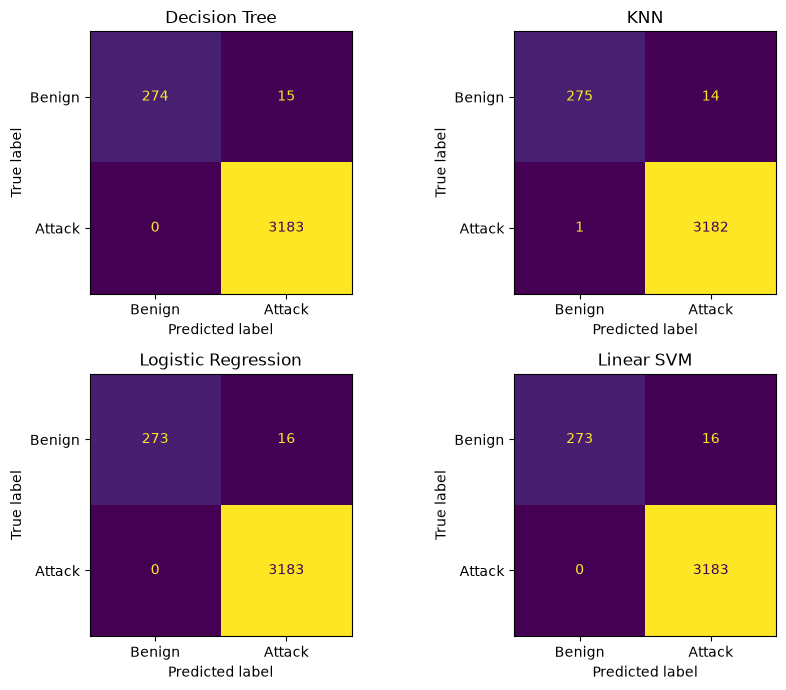

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, (name, matrix) in zip(axes.ravel(), confusion_matrices.items()):
    ConfusionMatrixDisplay(matrix, display_labels=['Benign', 'Attack']).plot(
        ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()